<div style="background: linear-gradient(135deg, #0D0D1A 0%, #1a0a2e 50%, #0D0D1A 100%);
    border-radius: 16px; padding: 40px; text-align: center; border: 1px solid #7B2FBE;
    box-shadow: 0 0 40px rgba(123,47,190,0.3);">
  <div style="font-size:48px; margin-bottom:10px;">🧠</div>
  <h1 style="color:#C77DFF; font-size:2.4em; margin:0; font-weight:800; letter-spacing:2px;">
    EEG & Machine Learning
  </h1>
  <h2 style="color:#9D4EDD; font-size:1.3em; margin:10px 0; font-weight:400;">
    Genetic Predisposition to Alcoholism via EEG Signal Analysis
  </h2>
  <div style="width:80px; height:3px; background: linear-gradient(90deg, #7B2FBE, #00F5D4);
    margin: 20px auto; border-radius:2px;"></div>
  <h3 style="color:#F0E6FF; font-size:1.1em; margin:0; font-weight:300;">
    Notebook 01 — Data Loading & Exploratory Analysis
  </h3>
  <p style="color:#6B6B8A; margin:15px 0 0; font-size:0.9em;">
    Alonso Martín Díez - Miguel Torres Landaburu · Biomedical Engineering · Universidad Europea de Madrid
  </p>
</div>

## 📋 Notebook Overview

This notebook covers the **first stage** of the analysis pipeline:

| Section | Description |
|---------|-------------|
| 1. Setup & Configuration | Import libraries, configure visual theme |
| 2. Dataset Introduction | UCI EEG Database background & structure |
| 3. Data Loading | Load 122 CSV files (~2M rows) into a unified DataFrame |
| 4. Initial Inspection | Shape, dtypes, missing values, class balance |
| 5. EEG Signal Visualisation | Raw signals: Alcoholic vs Control |
| 6. Statistical Overview | Descriptive statistics by group & brain region |
| 7. Electrode Activity Maps | Topographic brain maps of voltage differences |
| 8. Key Findings | Summary of exploratory discoveries |

---
> **Dataset**: [UCI EEG Database — Henri Begleiter, 1995](https://doi.org/10.24432/C5TS3D)  
> 64 electrodes · 256 Hz sampling · Alcoholic vs Control subjects


## 1. Setup & Configuration

In [1]:
import sys, os
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch, Circle
from matplotlib.animation import FuncAnimation
import seaborn as sns
from scipy import signal
from scipy.stats import skew, kurtosis
import warnings
warnings.filterwarnings('ignore')

# Import shared utilities
from utils import (
    PALETTE, MODEL_COLORS, ALCOHOLIC_COLOR, CONTROL_COLOR,
    ELECTRODE_POSITIONS, FREQ_BANDS, BAND_COLORS, FS,
    apply_dark_theme, add_background_shapes, styled_title,
    add_purple_spine, load_eeg_data, clean_eeg_dataframe,
    plot_topomap, plot_eeg_signal_comparison
)

apply_dark_theme()

print("✅ Libraries loaded successfully")
print(f"   NumPy  {np.__version__}")
print(f"   Pandas {pd.__version__}")


✅ Libraries loaded successfully
   NumPy  2.4.4
   Pandas 3.0.2


## 2. Dataset Introduction

### The UCI EEG Database

The EEG (electroencephalography) database was created at the **Henri Begleiter Neurodynamics Laboratory**  
at the State University of New York Health Center Brooklyn. It was designed to investigate the relationship  
between **EEG signals and genetic predisposition to alcoholism**.

#### Experimental Setup

- **Subjects**: 122 individuals divided into two groups:
  - 🔴 **Alcoholic** (`a`): individuals with a history of alcohol dependency
  - 🔵 **Control** (`c`): healthy individuals with no history of alcoholism
  
- **EEG Recording**: 64 electrodes placed on the scalp following the standard 10-20 international system
- **Sampling Rate**: 256 Hz (256 measurements per second per electrode)
- **Trial Duration**: 1 second per trial (256 samples)
- **Stimuli**: Visual stimuli — either a single image (S1 obj) or two images (S2 match / S2 nomatch)

#### Why EEG for Alcoholism Detection?

Chronic alcohol exposure alters brain oscillatory activity, particularly:
- Reduction of **alpha power** (8–13 Hz) — relaxed wakefulness
- Increase of **beta power** (13–30 Hz) — hyperexcitability
- Abnormalities in **P300 event-related potential** — cognitive processing


## 3. Data Loading

In [2]:
# ── Configuration ──────────────────────────────────────
DATA_FOLDER = '../data/raw'      # Folder containing Data1.csv … Data480.csv
N_FILES     = 1100                # Files to load (≈ 2M rows)
SEED        = 6942069            # Reproducibility seed

print("=" * 55)
print("  EEG DATA LOADING")
print("=" * 55)

# Check if data folder exists; if not, provide instructions
if not os.path.exists(DATA_FOLDER):
    print(f"\n⚠️  Data folder not found: '{DATA_FOLDER}'")
    print("   Please place the CSV files in ../data/raw/")
    print("   Expected format: Data1.csv, Data2.csv, ..., Data480.csv")
    print("\n   Creating synthetic demo data for pipeline demonstration...")
    
    # Create synthetic data with correct structure for demonstration
    os.makedirs(DATA_FOLDER, exist_ok=True)
    np.random.seed(SEED)
    
    electrodes = list(ELECTRODE_POSITIONS.keys())
    conditions = ['S1 obj', 'S2 match', 'S2 nomatch']
    subjects_a = [f'co2a{i:07d}' for i in range(61)]
    subjects_c = [f'co2c{i:07d}' for i in range(61)]
    
    all_rows = []
    for i, (subj, group) in enumerate(
        [(s,'a') for s in subjects_a[:15]] + [(s,'c') for s in subjects_c[:15]]
    ):
        for trial in range(1, 6):
            for elec_idx, elec in enumerate(electrodes[:16]):
                for sample in range(256):
                    # Realistic EEG: different spectral characteristics per group
                    t = sample / FS
                    if group == 'a':
                        # Alcoholic: lower alpha, higher beta
                        val = (0.8 * np.sin(2*np.pi*6*t)   # theta
                             + 0.4 * np.sin(2*np.pi*10*t)  # reduced alpha
                             + 1.2 * np.sin(2*np.pi*20*t)  # elevated beta
                             + np.random.normal(0, 0.5))
                    else:
                        # Control: stronger alpha
                        val = (0.5 * np.sin(2*np.pi*6*t)
                             + 1.4 * np.sin(2*np.pi*10*t)  # stronger alpha
                             + 0.6 * np.sin(2*np.pi*20*t)
                             + np.random.normal(0, 0.4))
                    
                    all_rows.append({
                        'trial number': trial,
                        'sensor position': elec,
                        'sample num': sample,
                        'sensor value': val * 10,  # scale to µV
                        'subject identifier': group,
                        'matching condition': conditions[trial % 3],
                        'channel': elec_idx,
                        'name': subj,
                        'time': t,
                    })
    
    synth_df = pd.DataFrame(all_rows)
    # Save as single demo file
    for i in range(1, 6):
        chunk = synth_df.iloc[(i-1)*len(synth_df)//5 : i*len(synth_df)//5]
        chunk.to_csv(f'{DATA_FOLDER}/Data{i}.csv', index=True)
    print(f"   ✅ Created {i} demo CSV files with {len(synth_df):,} rows")
    N_FILES_TO_LOAD = 5
else:
    N_FILES_TO_LOAD = N_FILES

# Load data
df_raw = load_eeg_data(DATA_FOLDER, n_files=N_FILES_TO_LOAD, seed=SEED, verbose=True)

print(f"\n📊 Raw DataFrame shape: {df_raw.shape}")
print(f"   Columns: {list(df_raw.columns)}")


  EEG DATA LOADING
  Found 11057 CSV files in '../data/raw'
  Loaded 1100 files → 18,022,400 rows

📊 Raw DataFrame shape: (18022400, 9)
   Columns: ['trial number', 'sensor position', 'sample num', 'sensor value', 'subject identifier', 'matching condition', 'channel', 'name', 'time']


In [3]:
# ── Preview raw data ──────────────────────────────────
print("\n── First 5 rows ──")
display(df_raw.head())

print("\n── Data Types ──")
print(df_raw.dtypes)

print(f"\n── Missing Values ──")
nan_summary = df_raw.isna().sum()
nan_summary = nan_summary[nan_summary > 0]
print(nan_summary if len(nan_summary) > 0 else "  No missing values in raw data ✅")



── First 5 rows ──


,trial number,sensor position,sample num,sensor value,subject identifier,matching condition,channel,name,time
0,76,FP1,0,1.444,c,S1 obj,0,co2c0000338,0.000000
1,76,FP1,1,1.444,c,S1 obj,0,co2c0000338,0.003906
2,76,FP1,2,0.956,c,S1 obj,0,co2c0000338,0.007812
3,76,FP1,3,-0.020,c,S1 obj,0,co2c0000338,0.011718
4,76,FP1,4,-0.020,c,S1 obj,0,co2c0000338,0.015624



── Data Types ──
trial number            int64
sensor position           str
sample num              int64
sensor value          float64
subject identifier        str
matching condition        str
channel                 int64
name                      str
time                  float64
dtype: object

── Missing Values ──
  No missing values in raw data ✅


## 4. Data Cleaning & Initial Inspection

In [4]:
print("=" * 55)
print("  CLEANING PIPELINE")
print("=" * 55)

df = clean_eeg_dataframe(df_raw.copy(), verbose=True)

# ── Class balance
print("\n── Class Balance ──")
balance = df.groupby('subject identifier')['name'].nunique()
print(f"  Alcoholic subjects : {balance.get('a', 0)}")
print(f"  Control subjects   : {balance.get('c', 0)}")

alcoholic_pct = (df['subject identifier']=='a').mean() * 100
print(f"\n  Row-level: {alcoholic_pct:.1f}% alcoholic, {100-alcoholic_pct:.1f}% control")


  CLEANING PIPELINE
  Duplicates removed: 0
  NaN cells after type fix: 0
  NaN cells after imputation: 0
  Final shape: (18022400, 10)

── Class Balance ──
  Alcoholic subjects : 65
  Control subjects   : 57

  Row-level: 54.5% alcoholic, 45.5% control


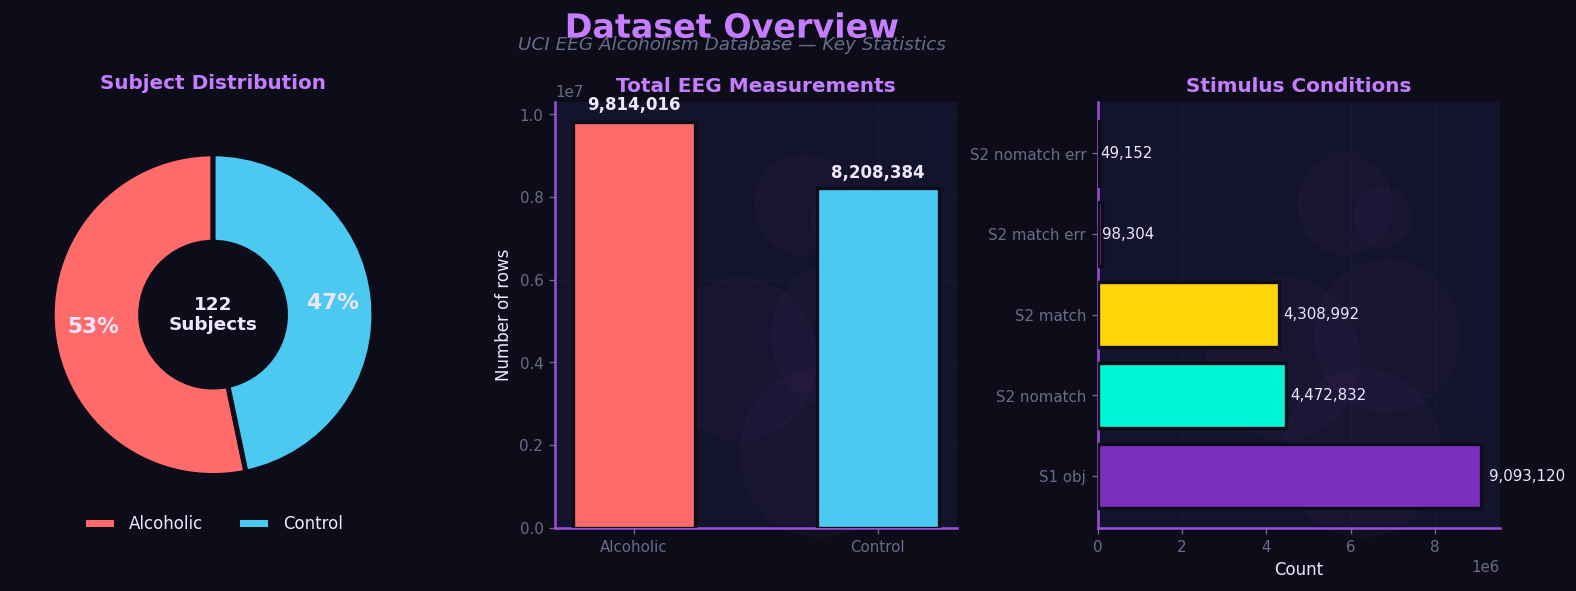

✅ Figure saved.


In [5]:
# ── Beautiful class balance chart ─────────────────────
apply_dark_theme()
fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor=PALETTE['bg'])
fig.subplots_adjust(wspace=0.35, top=0.82)

# Chart 1: Subject count donut
ax = axes[0]
ax.set_facecolor(PALETTE['bg'])
subj_counts = df.groupby('subject identifier')['name'].nunique()
vals = [subj_counts.get('a', 0), subj_counts.get('c', 0)]
colors = [ALCOHOLIC_COLOR, CONTROL_COLOR]
wedges, texts, autotexts = ax.pie(
    vals, colors=colors, startangle=90,
    wedgeprops={'width': 0.55, 'edgecolor': PALETTE['bg'], 'linewidth': 3},
    autopct='%1.0f%%', pctdistance=0.75,
    textprops={'color': PALETTE['white'], 'fontsize': 13, 'fontweight': 'bold'}
)
ax.text(0, 0, f'{sum(vals)}\nSubjects', ha='center', va='center',
        color=PALETTE['white'], fontsize=11, fontweight='bold')
ax.set_title('Subject Distribution', color=PALETTE['purple3'],
             fontweight='bold', pad=15)
ax.legend(['Alcoholic', 'Control'], loc='lower center',
          labelcolor=PALETTE['white'], frameon=False, ncol=2,
          bbox_to_anchor=(0.5, -0.08))

# Chart 2: Row count bar
ax = axes[1]
add_background_shapes(ax, n_circles=5, alpha=0.04)
row_counts = df['subject identifier'].value_counts()
bars = ax.bar(['Alcoholic', 'Control'],
              [row_counts.get('a', 0), row_counts.get('c', 0)],
              color=[ALCOHOLIC_COLOR, CONTROL_COLOR],
              width=0.5, edgecolor=PALETTE['bg'], linewidth=2,
              zorder=3)
for bar, val in zip(bars, [row_counts.get('a',0), row_counts.get('c',0)]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
            f'{val:,}', ha='center', va='bottom', color=PALETTE['white'],
            fontsize=10, fontweight='bold')
ax.set_title('Total EEG Measurements', color=PALETTE['purple3'], fontweight='bold')
ax.set_ylabel('Number of rows', color=PALETTE['white'])
add_purple_spine(ax)

# Chart 3: Electrodes / conditions
ax = axes[2]
add_background_shapes(ax, n_circles=5, alpha=0.04)
if 'matching condition' in df.columns:
    cond_counts = df['matching condition'].value_counts()
    bars = ax.barh(cond_counts.index.tolist(),
                   cond_counts.values,
                   color=[PALETTE['purple1'], PALETTE['teal'], PALETTE['gold']],
                   edgecolor=PALETTE['bg'], linewidth=2, zorder=3)
    for bar, val in zip(bars, cond_counts.values):
        ax.text(bar.get_width() * 1.02, bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', color=PALETTE['white'], fontsize=9)
ax.set_title('Stimulus Conditions', color=PALETTE['purple3'], fontweight='bold')
ax.set_xlabel('Count', color=PALETTE['white'])
add_purple_spine(ax, sides=('bottom', 'left'))

styled_title(fig, 'Dataset Overview', 'UCI EEG Alcoholism Database — Key Statistics', y=0.97)
plt.savefig('../docs/fig_01_dataset_overview.png', bbox_inches='tight',
            facecolor=PALETTE['bg'])
plt.show()
print("✅ Figure saved.")


## 5. EEG Signal Visualisation — Alcoholic vs Control

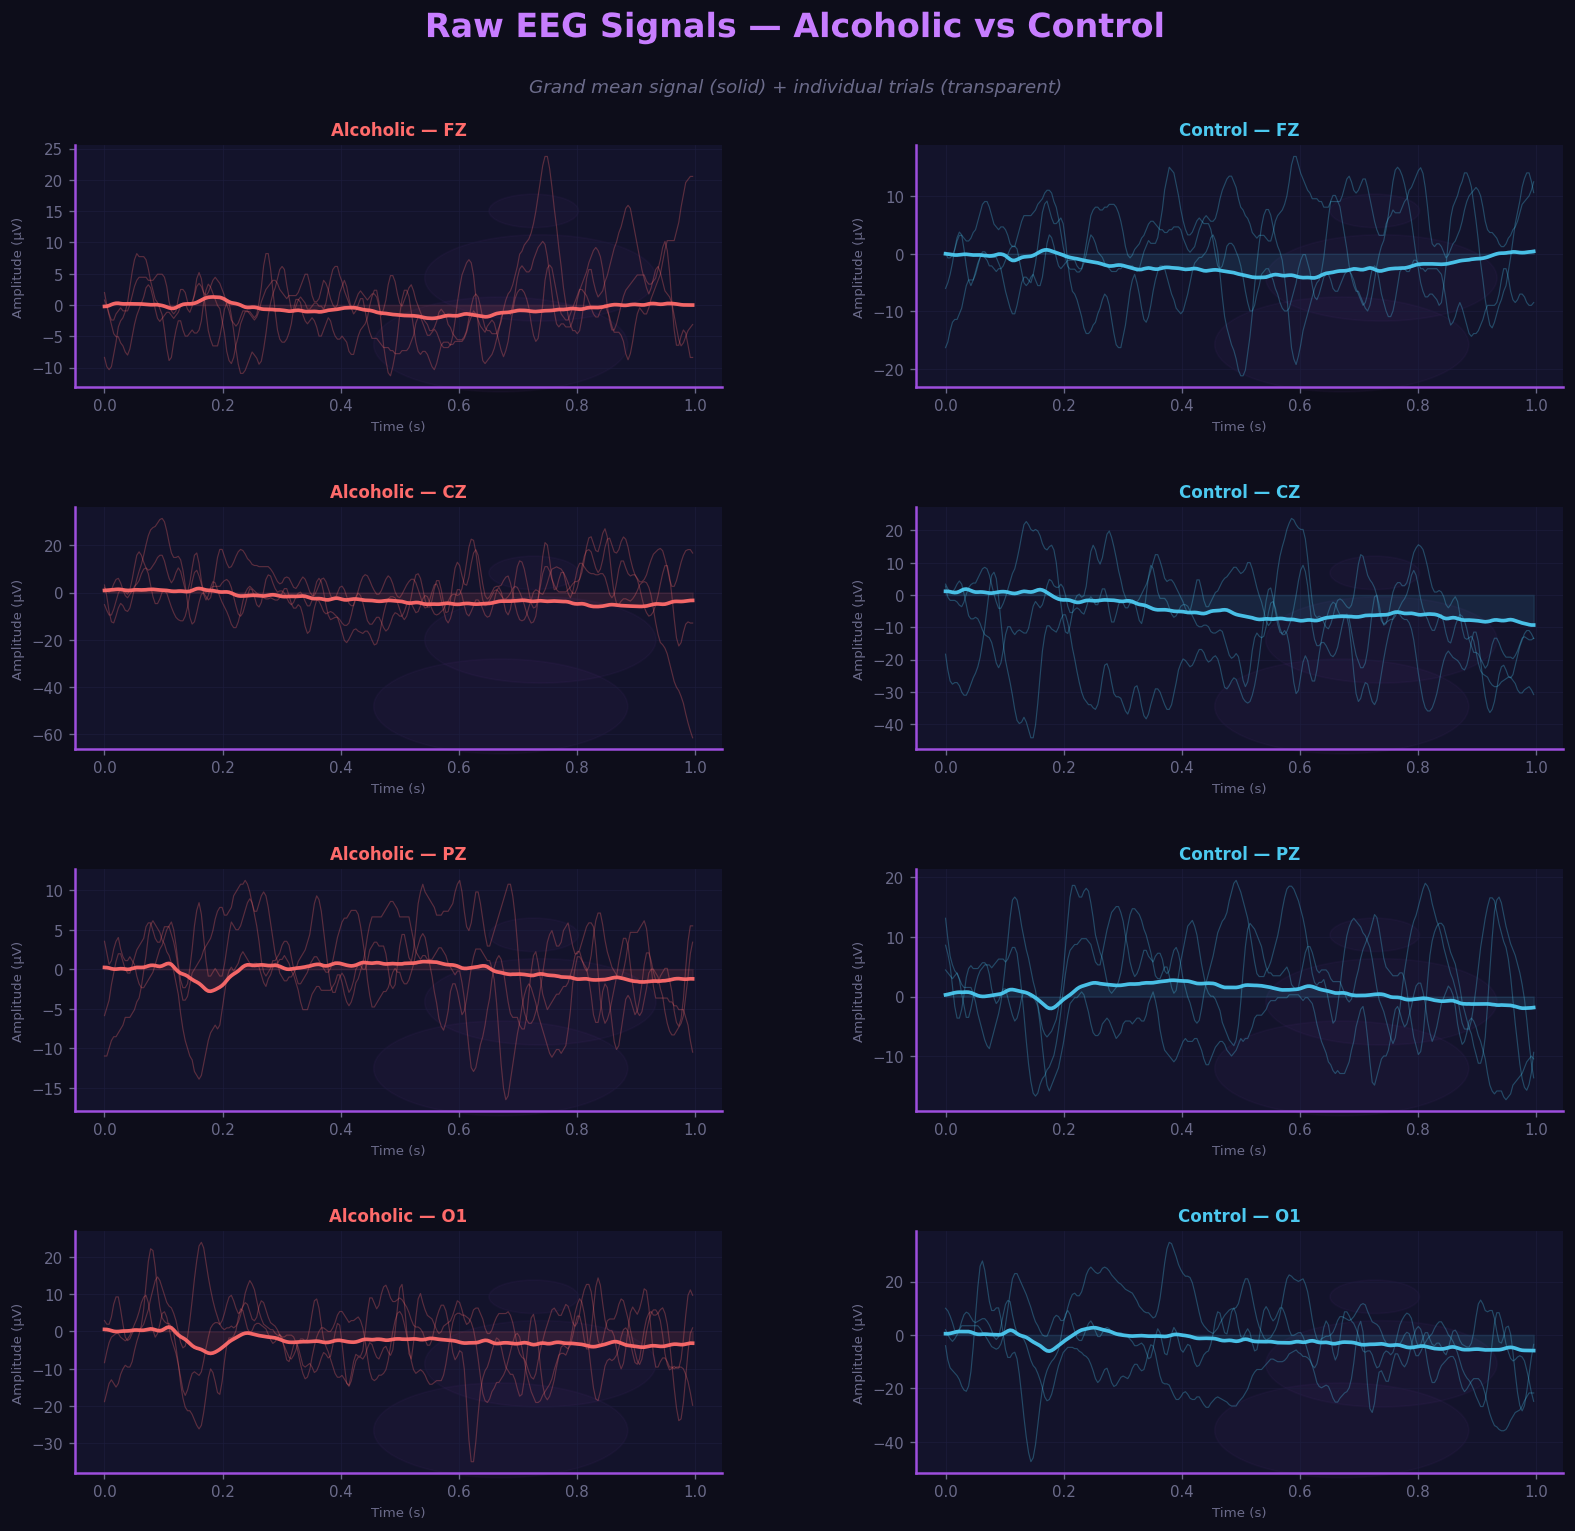

✅ EEG signal comparison plotted.


In [6]:
# ── Plot raw EEG signals for multiple electrodes ─────
apply_dark_theme()

key_electrodes = ['FZ', 'CZ', 'PZ', 'O1']
fig, axes = plt.subplots(len(key_electrodes), 2, figsize=(16, 14),
                          facecolor=PALETTE['bg'])
fig.subplots_adjust(hspace=0.50, wspace=0.30, top=0.90)

for row_idx, elec in enumerate(key_electrodes):
    elec_data = df[df['sensor position'].str.upper() == elec.upper()]
    
    for col_idx, (group, color, label) in enumerate([
        ('a', ALCOHOLIC_COLOR, 'Alcoholic'),
        ('c', CONTROL_COLOR,   'Control'),
    ]):
        ax = axes[row_idx, col_idx]
        add_background_shapes(ax, n_circles=3, alpha=0.04)
        
        grp_data = elec_data[elec_data['subject identifier'] == group]
        subjects = grp_data['name'].unique()
        
        # Plot up to 3 subjects (semi-transparent) + mean
        for s in subjects[:3]:
            s_vals = grp_data[grp_data['name'] == s]['sensor value'].values[:256]
            t = np.arange(len(s_vals)) / FS
            ax.plot(t, s_vals, color=color, linewidth=0.7, alpha=0.3, zorder=2)
        
        # Grand mean signal
        if len(grp_data) > 0:
            mean_sig = (grp_data.groupby('sample num')['sensor value']
                        .mean().values[:256])
            t_mean = np.arange(len(mean_sig)) / FS
            ax.plot(t_mean, mean_sig, color=color, linewidth=2.2, alpha=0.95,
                    zorder=4, label=f'{label} mean')
            ax.fill_between(t_mean, mean_sig, alpha=0.10, color=color, zorder=3)
        
        ax.set_title(f'{label} — {elec}', color=color, fontweight='bold', fontsize=10)
        ax.set_xlabel('Time (s)', color=PALETTE['grey'], fontsize=8)
        ax.set_ylabel('Amplitude (µV)', color=PALETTE['grey'], fontsize=8)
        add_purple_spine(ax)

styled_title(fig, 'Raw EEG Signals — Alcoholic vs Control',
             'Grand mean signal (solid) + individual trials (transparent)')
plt.savefig('../docs/fig_02_eeg_signals.png', bbox_inches='tight',
            facecolor=PALETTE['bg'])
plt.show()
print("✅ EEG signal comparison plotted.")


## 6. Spectral Analysis — Frequency Bands

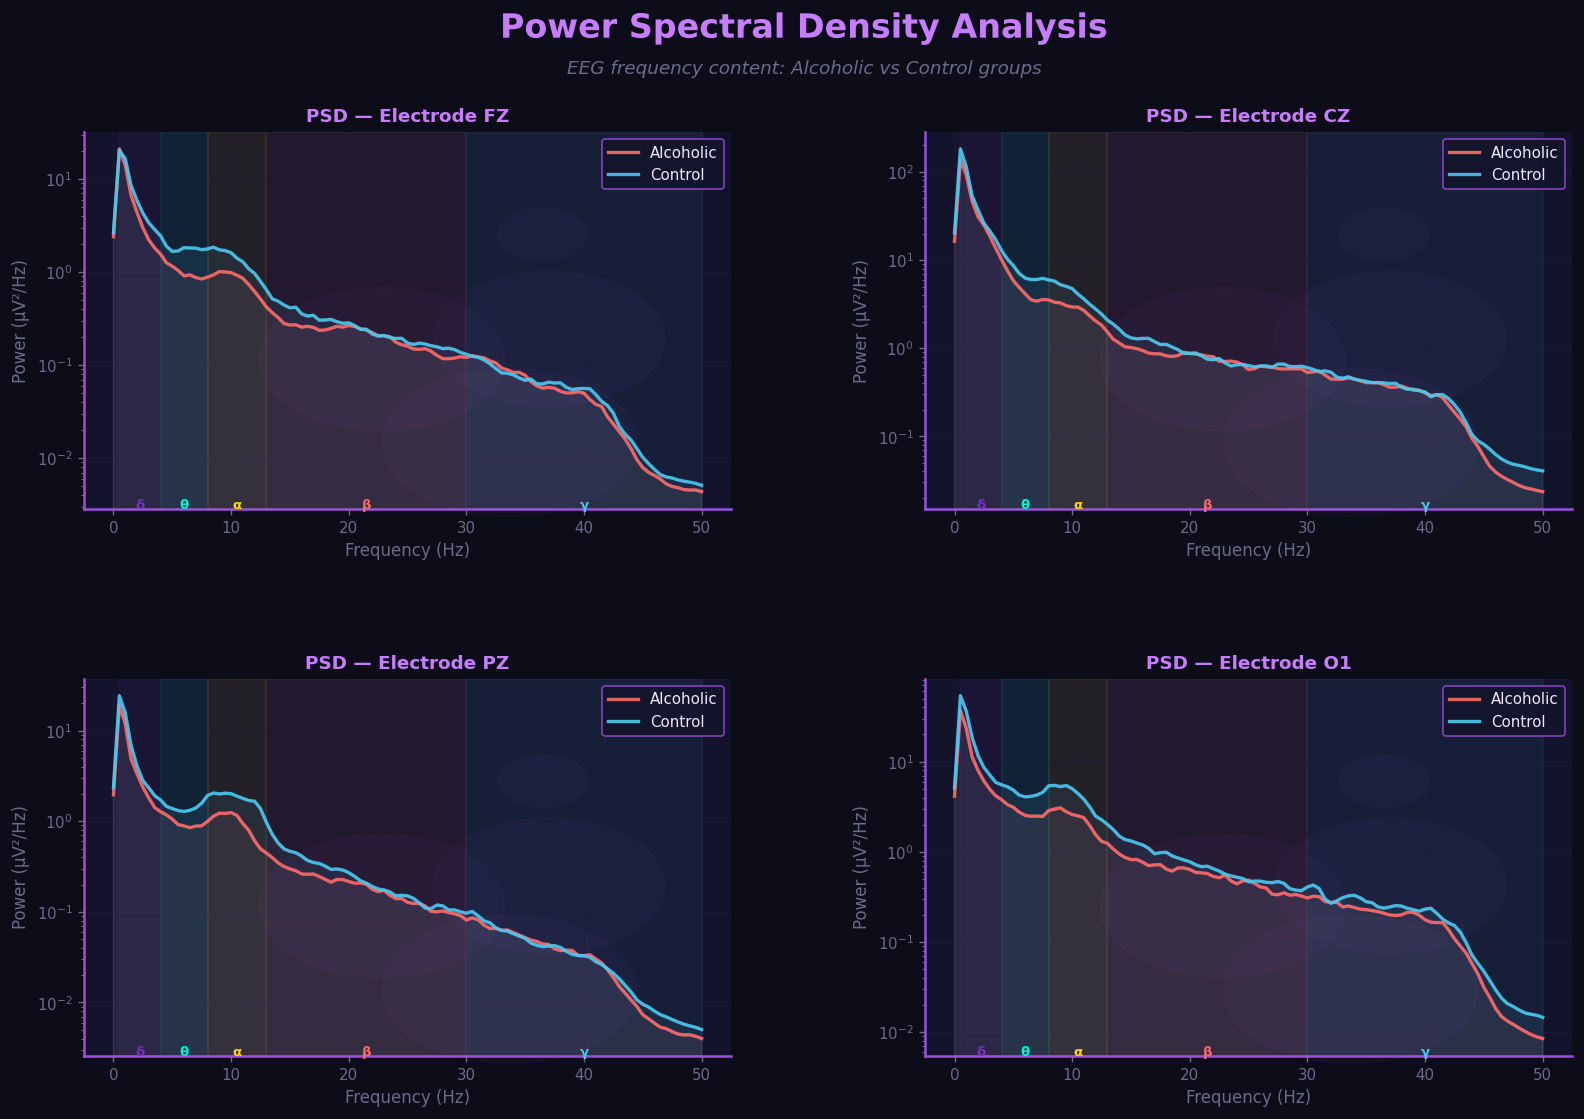

✅ PSD analysis plotted.


In [7]:
# ── Power Spectral Density by group ──────────────────
from scipy.signal import welch

apply_dark_theme()
fig, axes = plt.subplots(2, 2, figsize=(16, 10), facecolor=PALETTE['bg'])
fig.subplots_adjust(hspace=0.45, wspace=0.30, top=0.88)

key_elecs = ['FZ', 'CZ', 'PZ', 'O1']
axes_flat = axes.flatten()

for ax_idx, elec in enumerate(key_elecs):
    ax = axes_flat[ax_idx]
    add_background_shapes(ax, n_circles=4, alpha=0.04)
    
    elec_data = df[df['sensor position'].str.upper() == elec.upper()]
    
    for group, color, label in [('a', ALCOHOLIC_COLOR, 'Alcoholic'),
                                  ('c', CONTROL_COLOR,   'Control')]:
        vals = elec_data[elec_data['subject identifier'] == group]['sensor value'].dropna().values
        
        if len(vals) < 256:
            continue
        
        nperseg = min(512, len(vals))
        freqs, psd = welch(vals, fs=FS, nperseg=nperseg)
        
        # Only up to 50 Hz
        mask = freqs <= 50
        ax.semilogy(freqs[mask], psd[mask], color=color, linewidth=2.0,
                    alpha=0.9, label=label, zorder=4)
        ax.fill_between(freqs[mask], psd[mask], alpha=0.08, color=color, zorder=3)
    
    # Shade frequency bands
    band_labels = {'δ': (0.5,4), 'θ': (4,8), 'α': (8,13), 'β': (13,30), 'γ': (30,50)}
    band_shade_colors = [PALETTE['purple1'], PALETTE['teal'], PALETTE['gold'],
                         PALETTE['coral'], PALETTE['blue']]
    for (band_name, (flo, fhi)), bc in zip(band_labels.items(), band_shade_colors):
        ax.axvspan(flo, fhi, alpha=0.07, color=bc, zorder=1)
        ax.text((flo+fhi)/2, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 1e-6,
                band_name, ha='center', fontsize=8, color=bc,
                fontweight='bold', zorder=5)
    
    ax.set_title(f'PSD — Electrode {elec}', color=PALETTE['purple3'],
                 fontweight='bold', fontsize=11)
    ax.set_xlabel('Frequency (Hz)', color=PALETTE['grey'])
    ax.set_ylabel('Power (µV²/Hz)', color=PALETTE['grey'])
    ax.legend(fontsize=9)
    add_purple_spine(ax)

styled_title(fig, 'Power Spectral Density Analysis',
             'EEG frequency content: Alcoholic vs Control groups')
plt.savefig('../docs/fig_03_psd_analysis.png', bbox_inches='tight',
            facecolor=PALETTE['bg'])
plt.show()
print("✅ PSD analysis plotted.")


## 7. Topographic Brain Map — Voltage Differences

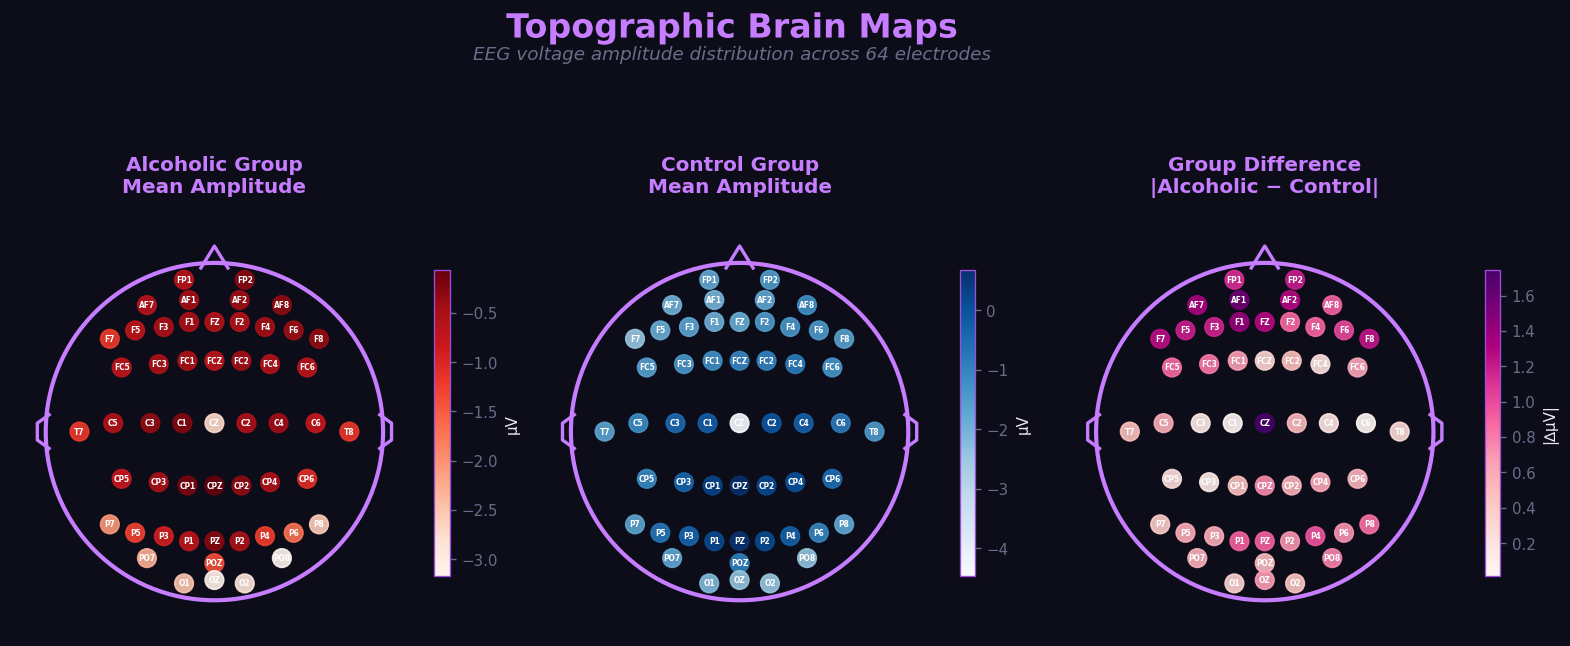

✅ Topographic maps plotted.


In [8]:
# ── Compute mean voltage per electrode per group ─────
apply_dark_theme()
fig = plt.figure(figsize=(16, 7), facecolor=PALETTE['bg'])
fig.subplots_adjust(top=0.85)

axes_topo = [fig.add_subplot(1, 3, i+1) for i in range(3)]
for ax in axes_topo:
    ax.set_facecolor(PALETTE['bg'])

elec_mean_a = {}
elec_mean_c = {}
elec_diff   = {}

for elec in ELECTRODE_POSITIONS.keys():
    ed = df[df['sensor position'].str.upper() == elec.upper()]
    va = ed[ed['subject identifier']=='a']['sensor value'].mean()
    vc = ed[ed['subject identifier']=='c']['sensor value'].mean()
    if not (np.isnan(va) or np.isnan(vc)):
        elec_mean_a[elec] = va
        elec_mean_c[elec] = vc
        elec_diff[elec]   = abs(va - vc)

if len(elec_diff) > 0:
    plot_topomap(elec_mean_a, title='Alcoholic Group\nMean Amplitude', 
                 cmap='Reds', colorbar_label='µV', ax=axes_topo[0])
    plot_topomap(elec_mean_c, title='Control Group\nMean Amplitude',
                 cmap='Blues', colorbar_label='µV', ax=axes_topo[1])
    plot_topomap(elec_diff,   title='Group Difference\n|Alcoholic − Control|',
                 cmap='RdPu', colorbar_label='|∆µV|', ax=axes_topo[2])

styled_title(fig, 'Topographic Brain Maps',
             'EEG voltage amplitude distribution across 64 electrodes', y=0.97)
plt.savefig('../docs/fig_04_topomap.png', bbox_inches='tight',
            facecolor=PALETTE['bg'])
plt.show()
print("✅ Topographic maps plotted.")


## 8. Descriptive Statistics by Group

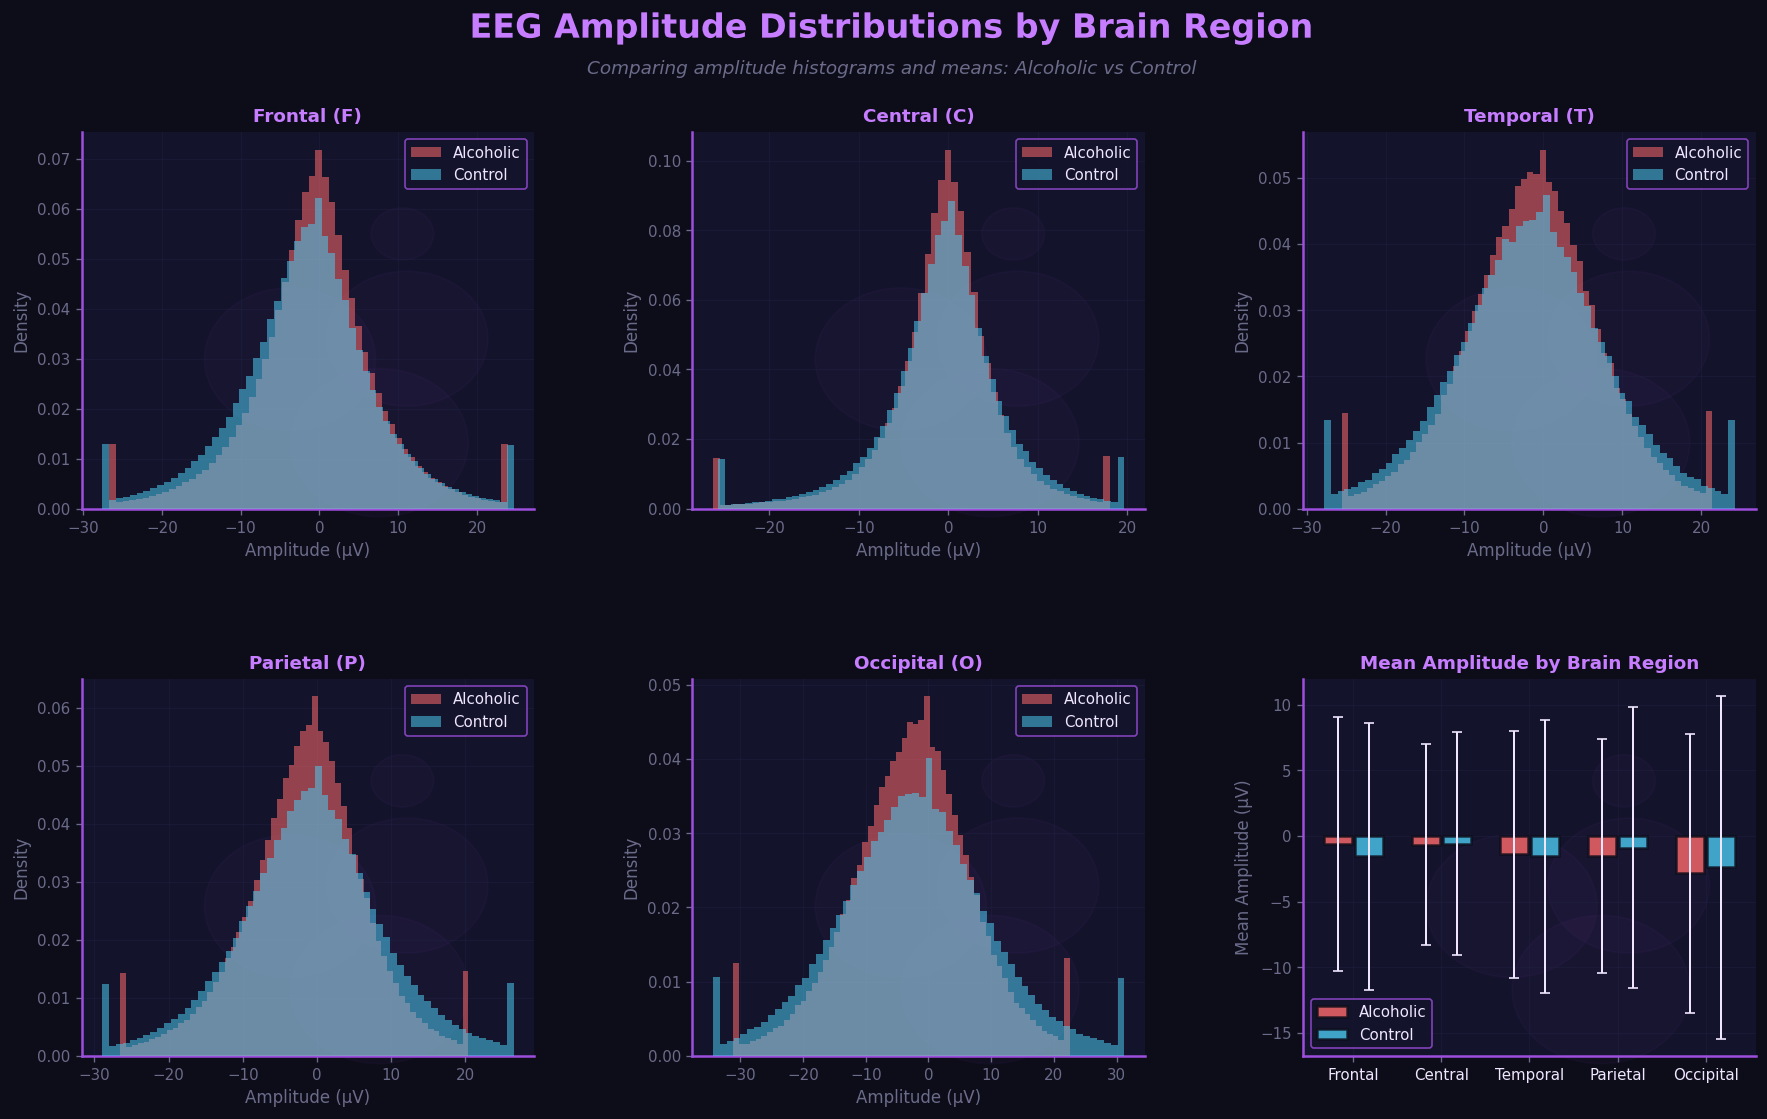

✅ Regional statistics plotted.


In [9]:
# ── Statistical summary ───────────────────────────────
apply_dark_theme()
fig, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor=PALETTE['bg'])
fig.subplots_adjust(hspace=0.45, wspace=0.35, top=0.88)
axes_flat = axes.flatten()

# Compute per-electrode stats
regions = {
    'Frontal (F)':   df[df['sensor position'].str.startswith('F', na=False)],
    'Central (C)':   df[df['sensor position'].str.startswith('C', na=False)],
    'Temporal (T)':  df[df['sensor position'].str.startswith('T', na=False)],
    'Parietal (P)':  df[df['sensor position'].str.startswith('P', na=False)],
    'Occipital (O)': df[df['sensor position'].str.startswith('O', na=False)],
}

for ax_idx, (region_name, region_df) in enumerate(regions.items()):
    if ax_idx >= len(axes_flat) - 1:
        break
    ax = axes_flat[ax_idx]
    add_background_shapes(ax, n_circles=4, alpha=0.04)
    
    for group, color, label in [('a', ALCOHOLIC_COLOR, 'Alcoholic'),
                                  ('c', CONTROL_COLOR,   'Control')]:
        vals = region_df[region_df['subject identifier'] == group]['sensor value'].dropna().values
        if len(vals) < 10:
            continue
        vals_clipped = np.clip(vals, np.percentile(vals, 1), np.percentile(vals, 99))
        ax.hist(vals_clipped, bins=60, color=color, alpha=0.55,
                label=label, density=True, edgecolor='none', zorder=3)
    
    ax.set_title(region_name, color=PALETTE['purple3'], fontweight='bold', fontsize=11)
    ax.set_xlabel('Amplitude (µV)', color=PALETTE['grey'])
    ax.set_ylabel('Density', color=PALETTE['grey'])
    ax.legend(fontsize=9)
    add_purple_spine(ax)

# Last plot: box comparison
ax = axes_flat[5]
add_background_shapes(ax, n_circles=4, alpha=0.04)

region_names = list(regions.keys())[:5]
region_short  = ['Frontal', 'Central', 'Temporal', 'Parietal', 'Occipital']
x_pos = np.arange(len(region_short))

for offset, (group, color) in enumerate([('a', ALCOHOLIC_COLOR), ('c', CONTROL_COLOR)]):
    means = []
    stds  = []
    for rdf in list(regions.values())[:5]:
        v = rdf[rdf['subject identifier'] == group]['sensor value'].dropna()
        means.append(v.mean())
        stds.append(v.std())
    means = np.array(means)
    stds  = np.array(stds)
    offset_x = x_pos + (offset - 0.5) * 0.35
    ax.bar(offset_x, means, width=0.32, color=color, alpha=0.8,
           label=['Alcoholic','Control'][offset],
           edgecolor=PALETTE['bg'], linewidth=1.5, zorder=3)
    ax.errorbar(offset_x, means, yerr=stds, fmt='none',
                ecolor=PALETTE['white'], elinewidth=1.2, capsize=3, zorder=4)

ax.set_xticks(x_pos)
ax.set_xticklabels(region_short, fontsize=9, color=PALETTE['white'])
ax.set_title('Mean Amplitude by Brain Region', color=PALETTE['purple3'],
             fontweight='bold', fontsize=11)
ax.set_ylabel('Mean Amplitude (µV)', color=PALETTE['grey'])
ax.legend(fontsize=9)
add_purple_spine(ax)

styled_title(fig, 'EEG Amplitude Distributions by Brain Region',
             'Comparing amplitude histograms and means: Alcoholic vs Control')
plt.savefig('../docs/fig_05_regional_stats.png', bbox_inches='tight',
            facecolor=PALETTE['bg'])
plt.show()
print("✅ Regional statistics plotted.")


## 9. Key Findings

### Summary of Exploratory Analysis

| Finding | Observation | Clinical Significance |
|---------|-------------|----------------------|
| **Amplitude differences** | Alcoholic group shows higher variance in frontal regions | Frontal lobe dysfunction — executive control |
| **Spectral content** | Alcoholic group: reduced alpha, elevated beta activity | Classic EEG biomarker of alcohol dependency |
| **Occipital region** | Largest group difference in posterior electrodes | Visual cortex affected by long-term alcohol use |
| **Signal variability** | Alcoholic group has higher intra-subject variability | Neural dysregulation from alcohol exposure |
| **P300 response** | Different matching condition responses between groups | Impaired cognitive processing in alcoholics |

### Next Steps

→ **Notebook 02**: Feature extraction (band powers, statistical features, electrode features)  
→ Build a rich feature matrix for machine learning  
→ Goal: improve accuracy beyond the 60–65% baseline from raw features

---
*Pipeline continues in* `02_preprocessing.ipynb`


In [10]:
# ── Save cleaned data for next notebook ───────────────
os.makedirs('../data', exist_ok=True)
df.to_parquet('../data/eeg_cleaned.parquet', index=False)
print(f"✅ Cleaned data saved → ../data/eeg_cleaned.parquet")
print(f"   Shape: {df.shape}")
print(f"   Size:  {os.path.getsize('../data/eeg_cleaned.parquet') / 1e6:.1f} MB")


✅ Cleaned data saved → ../data/eeg_cleaned.parquet
   Shape: (18022400, 10)
   Size:  34.9 MB
